# Benchmark Evaluation Using CS Bench Dataset

## Dataset Analysis

In [4]:
validation_dataset = '../datasets/benchmark/CS Bench/cs-bench-valid.jsonl'
test_dataset = '../datasets/benchmark/CS Bench/cs-bench-test.jsonl'

In [5]:
import json

questions = []
question_types = set()
domain_types = set()
subdomain_types = {}
tag_types = set()

with open(validation_dataset, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)

        question_types.add(record["Format"])
        domain_types.add(record["Domain"])
        tag_types.add(record["Tag"])

        if record["Domain"] not in subdomain_types:
            subdomain_types[record["Domain"]] = {record["SubDomain"]}
        else:
            subdomain_types[record["Domain"]].add(record["SubDomain"])

        questions.append(record)

with open(test_dataset, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        questions.append(record)

print(len(questions))
print(question_types)
print(domain_types)
print(subdomain_types)
print(tag_types)
print(questions[0])

2419
{'Assertion', 'Open-ended', 'Fill-in-the-blank', 'Multiple-choice'}
{'Operating System', 'Computer Network', 'Data Structure and Algorithm', 'Computer Organization'}
{'Data Structure and Algorithm': {'Graph', 'Overview', 'Linear List', 'Stack, Queue, and Array', 'Sorting', 'Tree', 'Searching', 'String'}, 'Computer Organization': {'Instruction System', 'Overview', 'Central Processing Unit', 'Data Representation and Operation', 'Input/Output System', 'Storage System', 'Bus'}, 'Computer Network': {'Data Link Layer', 'Application Layer', 'Overview and Architecture', 'Transport Layer', 'Network Layer', 'Physical Layer'}, 'Operating System': {'Memory Management', 'Overview', 'File Management', 'Input/Output Management', 'Processes and Threads'}}
{'Knowledge', 'Reasoning'}
{'ID': 2184, 'Split': 'Valid', 'Domain': 'Data Structure and Algorithm', 'SubDomain': 'Overview', 'Format': 'Multiple-choice', 'Tag': 'Knowledge', 'Language': 'English', 'Question': 'Do two different data structures ne

In [100]:
open_ended = [q for q in questions if q["Format"] == "Open-ended"]
print(len(open_ended))
print(open_ended[0])

189
{'ID': 2242, 'Split': 'Valid', 'Domain': 'Data Structure and Algorithm', 'SubDomain': 'Overview', 'Format': 'Open-ended', 'Tag': 'Reasoning', 'Language': 'English', 'Question': 'Are the logical structure and the physical structure necessarily different for two distinct data structures?', 'Answer': 'For two different data structures, it is entirely possible for their logical and physical structures to be the same. For example, binary trees and binary search trees can use the same logical representation and storage method of binary trees. The former is usually used to represent hierarchical relationships, while the latter is commonly used for sorting and searching. Although both have operations such as building a tree, inserting nodes, deleting nodes, and searching for nodes, the definitions of these operations are different for binary trees and binary search trees. Taking node search as an example, the time complexity for a binary tree is O(n), while for a binary search tree, the ti

In [101]:
assertion = [q for q in questions if q["Format"] == "Assertion"]
print(len(assertion))
print(assertion[0])

491
{'ID': 2228, 'Split': 'Valid', 'Domain': 'Data Structure and Algorithm', 'SubDomain': 'Linear List', 'Format': 'Assertion', 'Tag': 'Knowledge', 'Language': 'English', 'Question': 'The size of the storage space occupied by a sequential list is independent of the type of elements.', 'Answer': False}


In [102]:
fill_in_the_blank = [q for q in questions if q["Format"] == "Fill-in-the-blank"]
print(len(fill_in_the_blank))
print(fill_in_the_blank[0])

258
{'ID': 2240, 'Split': 'Valid', 'Domain': 'Data Structure and Algorithm', 'SubDomain': 'Tree', 'Format': 'Fill-in-the-blank', 'Tag': 'Reasoning', 'Language': 'English', 'Question': 'In a binary tree, if there are two nodes m and n, and m is an ancestor of n, then the path from m to n can be found using ().', 'Answer': 'Post-order', 'Explanation': 'During the post-order traversal return, visiting the root node allows us to output the nodes on the path from n to m in a bottom-up manner. If a non-recursive algorithm is used, when the post-order traversal reaches n, the nodes on the path from the root to n via parent pointers are all remembered in the stack, which can also be used to find the path from m to n.'}


In [103]:
benchmark_questions = [q for q in questions if q["Format"] in ["Multiple-choice","Assertion","Open-ended"] and q["Language"] == "English"]
print("Total:",len(benchmark_questions))
print("Multiple Choice:",(len(benchmark_questions)-len(assertion)))
print("Assertion:",len(assertion))
print("Open Ended:",len(open_ended))

Total: 2161
Multiple Choice: 1670
Assertion: 491
Open Ended: 189


In [7]:
benchmark_path = "../datasets/benchmark/CS Bench/cs-bench.jsonl"
with open(benchmark_path,"w",encoding="utf-8") as f:
    for q in questions:
        f.write(json.dumps(q, ensure_ascii=False))
        f.write("\n")

### Domain & Subdomain Statistics

In [105]:
domain_count = {}
for q in questions:
    domain = q["Domain"]
    sub_domain = q["SubDomain"]
    if domain not in domain_count:
        domain_count[domain] = {sub_domain : 1}
    else:
        if sub_domain not in domain_count[domain]:
            domain_count[domain][sub_domain] = 1
        else:
            domain_count[domain][sub_domain] += 1
print(domain_count)

{'Data Structure and Algorithm': {'Overview': 42, 'Linear List': 69, 'Stack, Queue, and Array': 88, 'String': 33, 'Tree': 107, 'Graph': 92, 'Searching': 79, 'Sorting': 89}, 'Computer Organization': {'Overview': 56, 'Data Representation and Operation': 109, 'Storage System': 112, 'Instruction System': 78, 'Central Processing Unit': 122, 'Bus': 67, 'Input/Output System': 78}, 'Computer Network': {'Overview and Architecture': 74, 'Physical Layer': 82, 'Data Link Layer': 158, 'Network Layer': 150, 'Transport Layer': 91, 'Application Layer': 102}, 'Operating System': {'Overview': 83, 'Processes and Threads': 175, 'Memory Management': 108, 'Input/Output Management': 92, 'File Management': 83}}


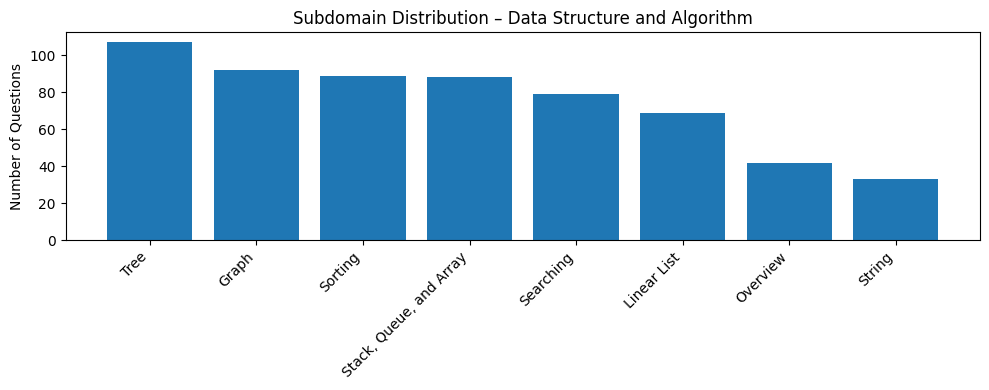

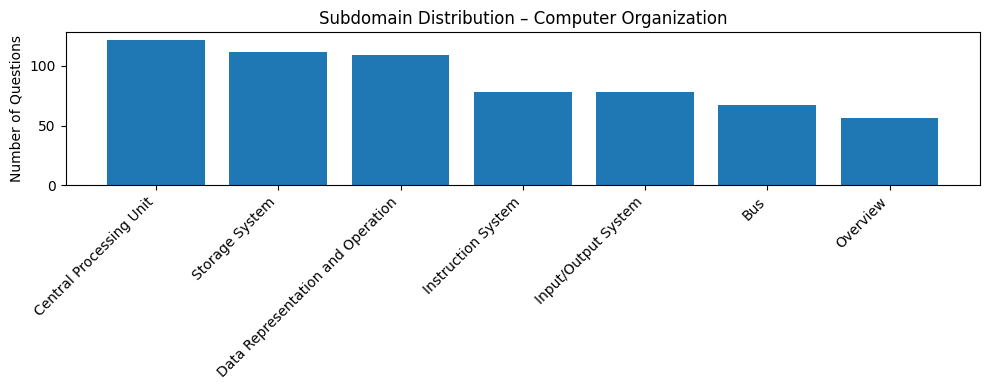

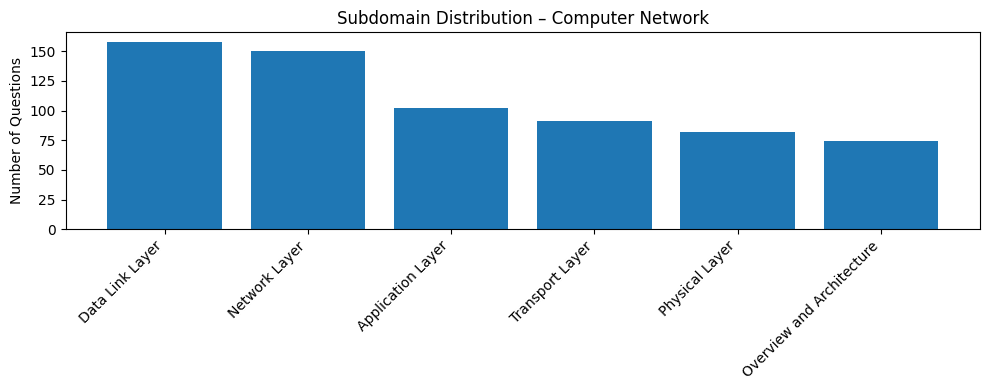

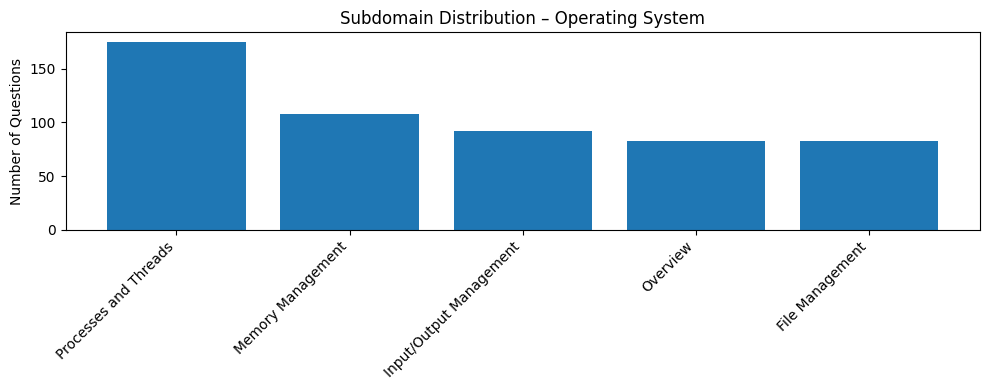

In [106]:
import matplotlib.pyplot as plt
def plot_domain_distributions_sorted(domain_count):
    for domain, subdomains in domain_count.items():
        items = sorted(subdomains.items(), key=lambda x: x[1], reverse=True)
        names = [k for k, _ in items]
        counts = [v for _, v in items]

        plt.figure(figsize=(10, 4))
        plt.bar(names, counts)
        plt.title(f"Subdomain Distribution – {domain}")
        plt.ylabel("Number of Questions")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
plot_domain_distributions_sorted(domain_count)

### Domain & Subdomain & Tag Statistics 

In [107]:
domain_distribution = {}
for q in questions:
    domain = q["Domain"]
    sub_domain = q["SubDomain"]
    tag = q["Tag"]
    if domain not in domain_distribution:
        domain_distribution[domain] = {sub_domain : { tag : 1}}
    else:
        if sub_domain not in domain_distribution[domain]:
            domain_distribution[domain][sub_domain] = {tag : 1}
        elif tag not in domain_distribution[domain][sub_domain]:
            domain_distribution[domain][sub_domain][tag] = 1
        else:
            domain_distribution[domain][sub_domain][tag] += 1
print(domain_distribution)

{'Data Structure and Algorithm': {'Overview': {'Knowledge': 36, 'Reasoning': 6}, 'Linear List': {'Knowledge': 52, 'Reasoning': 17}, 'Stack, Queue, and Array': {'Knowledge': 55, 'Reasoning': 33}, 'String': {'Knowledge': 28, 'Reasoning': 5}, 'Tree': {'Knowledge': 46, 'Reasoning': 61}, 'Graph': {'Knowledge': 59, 'Reasoning': 33}, 'Searching': {'Knowledge': 44, 'Reasoning': 35}, 'Sorting': {'Knowledge': 36, 'Reasoning': 53}}, 'Computer Organization': {'Overview': {'Knowledge': 45, 'Reasoning': 11}, 'Data Representation and Operation': {'Knowledge': 46, 'Reasoning': 63}, 'Storage System': {'Knowledge': 71, 'Reasoning': 41}, 'Instruction System': {'Knowledge': 53, 'Reasoning': 25}, 'Central Processing Unit': {'Knowledge': 93, 'Reasoning': 29}, 'Bus': {'Knowledge': 56, 'Reasoning': 11}, 'Input/Output System': {'Knowledge': 54, 'Reasoning': 24}}, 'Computer Network': {'Overview and Architecture': {'Knowledge': 63, 'Reasoning': 11}, 'Physical Layer': {'Knowledge': 55, 'Reasoning': 27}, 'Data Lin

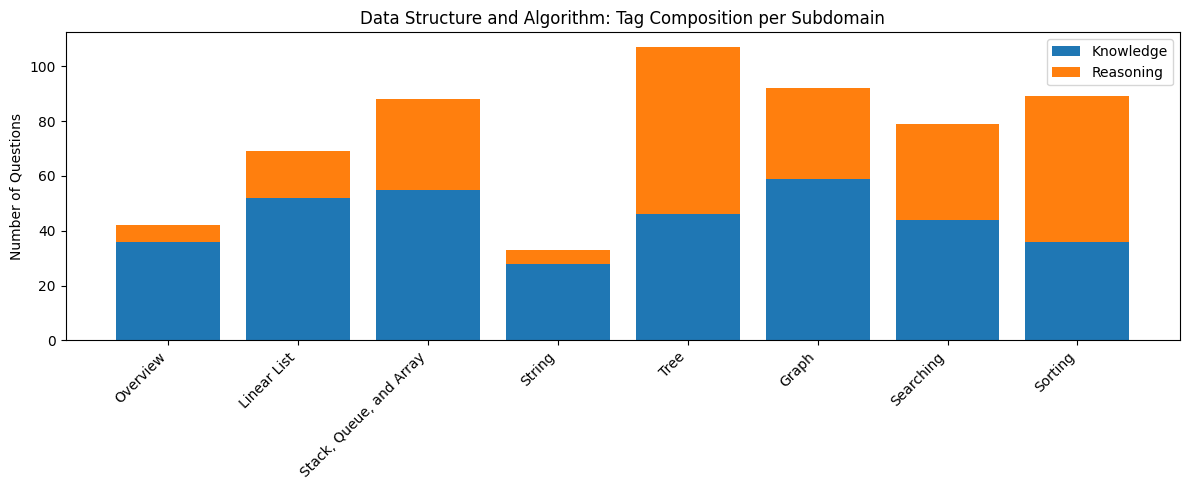

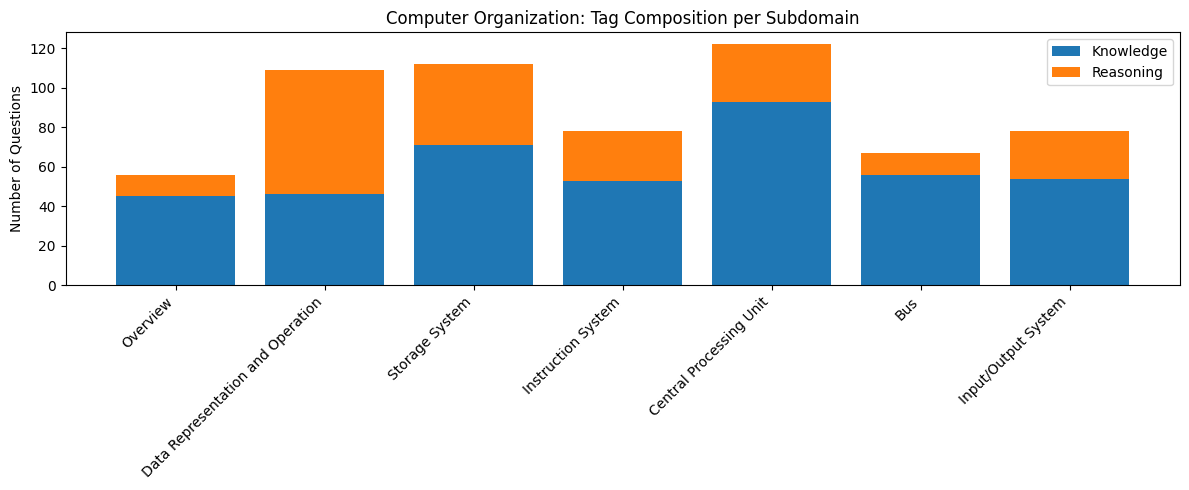

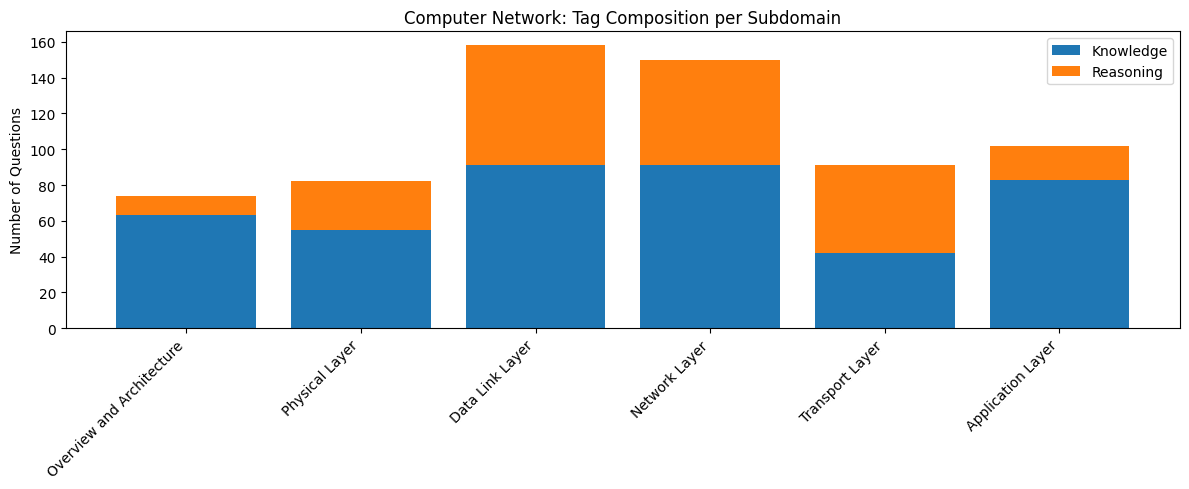

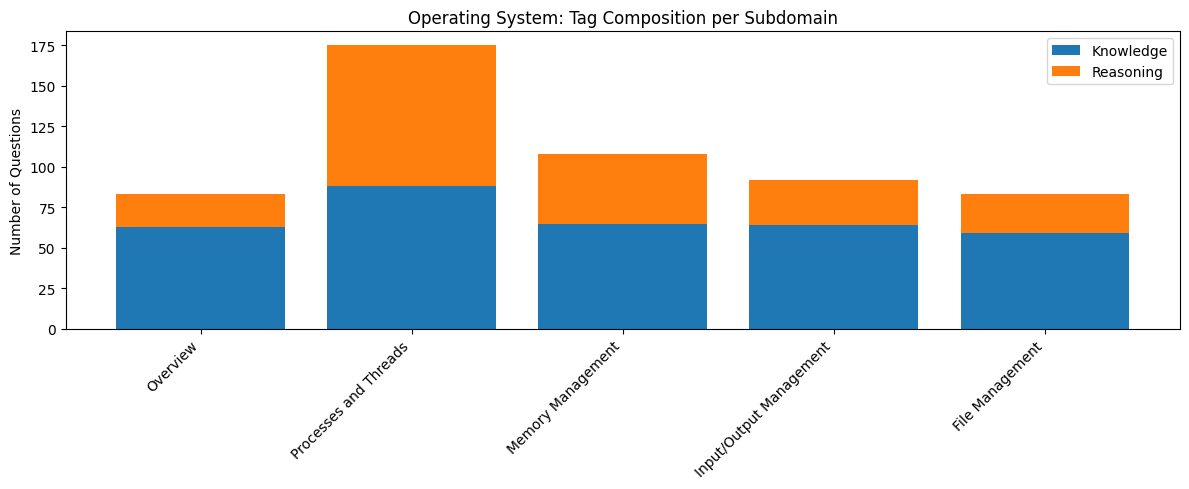

In [108]:
import numpy as np
def plot_domain_stacked(domain_distribution):
    for domain, subdomains in domain_distribution.items():
        subdomain_names = list(subdomains.keys())
        tags = set()

        for sd in subdomains.values():
            tags.update(sd.keys())
        tags = sorted(tags)

        bottom = np.zeros(len(subdomain_names))

        plt.figure(figsize=(12, 5))

        for tag in tags:
            values = [
                subdomains[sd].get(tag, 0)
                for sd in subdomain_names
            ]
            plt.bar(subdomain_names, values, bottom=bottom, label=tag)
            bottom += np.array(values)

        plt.title(f"{domain}: Tag Composition per Subdomain")
        plt.ylabel("Number of Questions")
        plt.xticks(rotation=45, ha="right")
        plt.legend()
        plt.tight_layout()
        plt.show()
plot_domain_stacked(domain_distribution)

### Multiple Choice Questions

In [109]:
mcqs = [q for q in benchmark_questions if q["Format"] == "Multiple-choice"]
total_mcqs = len(mcqs)
answer_distribution = {"A":0,"B":0,"C":0,"D":0}
for q in mcqs:
    answer_distribution[q["Answer"]] += 1
print(answer_distribution)
for key in "ABCD":
    print(f"{key} : {float(answer_distribution[key]/total_mcqs) * 100}")

{'A': 403, 'B': 384, 'C': 382, 'D': 312}
A : 27.211343686698175
B : 25.928426738690074
C : 25.79338284942606
D : 21.066846725185687


### Assertions

In [111]:
assertions = [q for q in benchmark_questions if q["Format"] == "Assertion"]
total_assertions = len(assertions)
answer_distribution = {"A":0,"B":0}
for q in assertions:
    option = "A" if q["Answer"] else "B"
    answer_distribution[option] += 1
print(answer_distribution)
for key in "AB":
    print(f"{key} : {float(answer_distribution[key]/total_assertions) * 100}")

{'A': 235, 'B': 256}
A : 47.86150712830957
B : 52.138492871690424


## Model Evaluation

### Only with MCQs and Assertions

In [17]:
!pip install -U transformers datasets evaluate accelerate timm

/bin/bash: /home/sasank-v/anaconda3/envs/ml/lib/libtinfo.so.6: no version information available (required by /bin/bash)
  Using cached accelerate-1.12.0-py3-none-any.whl.metadata (19 kB)
  Using cached pyarrow-23.0.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (3.0 kB)
  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-3.6.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
  Using cached aiohttp-3.13.3-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.1 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached async_timeout-5.0.1-py3-none-any.whl.metadata (5.1 kB)
  Using cached frozenlist-1.8.0-cp310-cp310-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (20 kB)
  Using cached multidict-6.7.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_1

In [31]:
prompt_template = """
You are a Computer Science domain expert.
You answer questions with maximum technical accuracy and zero speculation.
You do NOT explain your reasoning unless explicitly asked.
You do NOT restate the question.
You do NOT include any additional text, justification, or commentary.

You will be given:
1. A Question
2. A Question Type: one of
   - Assertion
   - Multiple-choice
3. Options

Rules:
1. Output ONLY the correct option identifier (A, B, C, or D).
2. Do NOT repeat the option text.
3. For Assertion questions, options are labeled:
   A) True
   B) False
   Output ONLY A or B.
4. Output format is strict.
5. Output must contain ONLY the answer.
6. No additional tokens, words, or punctuation are allowed.
7. If the question is ambiguous or incorrect, choose the most technically correct interpretation used in standard computer science literature.

Now answer the following:

Question:
{question}

Question Type:
{question_type}

Options:
{options}

Final Answer (ONE TOKEN ONLY):
"""

In [64]:
def generate_response(model, tokenizer, prompt, qtype):
    model_inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    max_tokens = 3
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=max_tokens,
        do_sample=False,
    )

    generated_tokens = generated_ids[:, model_inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated_tokens[0], skip_special_tokens=True)


def normalize_mcq(response):
    response = response.strip().upper()
    for ch in response:
        if ch in "ABCD":
            return ch
    return "-"


def normalize_assertion(response):
    response = response.strip().upper()
    for ch in response:
        if ch in "AB":
            return ch
    return "-"

def run_evaluation(model, tokenizer, questions):
    correct = 0
    generated_answers = {"Multiple-choice": {"A":0,"B":0,"C":0,"D":0,"-":0},"Assertion":{"A":0,"B":0,"-":0}}
    for i,question in enumerate(questions):
        qtype = question["Format"]
        content = question["Question"]
        answer = question["Answer"]

        if qtype == "Multiple-choice":
                options = (
                    f"A) {question['A']}\n"
                    f"B) {question['B']}\n"
                    f"C) {question['C']}\n"
                    f"D) {question['D']}"
                )
                prompt = prompt_template.format(
                    question=content,
                    question_type=qtype,
                    options=options
                )
                answer = answer[0]

        elif qtype == "Assertion":
                prompt = prompt_template.format(
                    question=content,
                    question_type=qtype,
                    options="A) True\nB) False"
                )

        response = generate_response(model, tokenizer, prompt,qtype).strip().lower()
        if qtype == "Multiple-choice":
            response = normalize_mcq(response)
        elif qtype == "Assertion":
            response = normalize_assertion(response) 
            answer = "A" if answer else "B"

            
        print(f"---Q{i}/{len(questions)} | {qtype}---")
        print(answer, response, answer == response)
        if answer == response: 
            correct+=1
        generated_answers[qtype][response] += 1
        
    return (float(correct/len(questions) * 100),generated_answers)

#### 1.SMOL LM2 - 135M - Instruct

In [13]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")
model = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

In [17]:
smollm2_135m_accuracy,smollm2_135m_generated_answers = run_evaluation(model,tokenizer,benchmark_questions)

---Q0/1972 | Multiple-choice---
B D False
---Q1/1972 | Multiple-choice---
C A False
---Q2/1972 | Multiple-choice---
C B False
---Q3/1972 | Multiple-choice---
C A False
---Q4/1972 | Multiple-choice---
C A False
---Q5/1972 | Multiple-choice---
A B False
---Q6/1972 | Multiple-choice---
A B False
---Q7/1972 | Multiple-choice---
A D False
---Q8/1972 | Multiple-choice---
D D True
---Q9/1972 | Multiple-choice---
A A True
---Q10/1972 | Multiple-choice---
A D False
---Q11/1972 | Multiple-choice---
B A False
---Q12/1972 | Multiple-choice---
A A True
---Q13/1972 | Multiple-choice---
D D True
---Q14/1972 | Multiple-choice---
D D True
---Q15/1972 | Multiple-choice---
B A False
---Q16/1972 | Multiple-choice---
D D True
---Q17/1972 | Multiple-choice---
C A False
---Q18/1972 | Multiple-choice---
A A True
---Q19/1972 | Multiple-choice---
A A True
---Q20/1972 | Multiple-choice---
A D False
---Q21/1972 | Multiple-choice---
A A True
---Q22/1972 | Multiple-choice---
A B False
---Q23/1972 | Multiple-choice-

In [18]:
print(smollm2_135m_accuracy)
print(smollm2_135m_generated_answers["Multiple-choice"])
print(smollm2_135m_generated_answers["Assertion"])

30.324543610547668
{'A': 680, 'B': 84, 'C': 6, 'D': 697, '-': 14}
{'A': 209, 'B': 282, '-': 0}


#### 2. SMOL LM2 - 360M

In [19]:
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-360M")
model = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-360M")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [20]:
smollm2_360m_accuracy,smollm2_360m_generated_answers = run_evaluation(model,tokenizer,benchmark_questions)

Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


---Q0/1972 | Multiple-choice---
B A False


Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


---Q1/1972 | Multiple-choice---
C A False


Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


...

---Q1968/1972 | Assertion---
B A False


Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


---Q1969/1972 | Assertion---
B A False


Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


---Q1970/1972 | Assertion---
B A False
---Q1971/1972 | Assertion---
A A True


In [21]:
print(smollm2_360m_accuracy)
print(smollm2_360m_generated_answers["Multiple-choice"])
print(smollm2_360m_generated_answers["Assertion"])

31.135902636916835
{'A': 1406, 'B': 0, 'C': 5, 'D': 12, '-': 58}
{'A': 452, 'B': 0, '-': 39}


#### 3. Qwen2.5 - 0.5B - Instruct

In [22]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
qwen25_accuracy,qwen25_generated_answers = run_evaluation(model,tokenizer,benchmark_questions)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


---Q0/1972 | Multiple-choice---
B A False
---Q1/1972 | Multiple-choice---
C A False
---Q2/1972 | Multiple-choice---
C A False
---Q3/1972 | Multiple-choice---
C A False
---Q4/1972 | Multiple-choice---
C A False
---Q5/1972 | Multiple-choice---
A A True
---Q6/1972 | Multiple-choice---
A A True
---Q7/1972 | Multiple-choice---
A A True
---Q8/1972 | Multiple-choice---
D A False
---Q9/1972 | Multiple-choice---
A A True
---Q10/1972 | Multiple-choice---
A A True
---Q11/1972 | Multiple-choice---
B A False
---Q12/1972 | Multiple-choice---
A A True
---Q13/1972 | Multiple-choice---
D A False
---Q14/1972 | Multiple-choice---
D A False
---Q15/1972 | Multiple-choice---
B A False
---Q16/1972 | Multiple-choice---
D A False
---Q17/1972 | Multiple-choice---
C A False
---Q18/1972 | Multiple-choice---
A A True
---Q19/1972 | Multiple-choice---
A A True
---Q20/1972 | Multiple-choice---
A A True
---Q21/1972 | Multiple-choice---
A A True
---Q22/1972 | Multiple-choice---
A A True
---Q23/1972 | Multiple-choice---

In [23]:
print(qwen25_accuracy)
print(qwen25_generated_answers["Multiple-choice"])
print(qwen25_generated_answers["Assertion"])

32.454361054766736
{'A': 1445, 'B': 1, 'C': 8, 'D': 14, '-': 13}
{'A': 491, 'B': 0, '-': 0}


#### 4. Qwen3 - 0.6B

In [24]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3-0.6B")
qwen3_accuracy,qwen3_generated_answers = run_evaluation(model,tokenizer,benchmark_questions)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


---Q0/1972 | Multiple-choice---
B A False
---Q1/1972 | Multiple-choice---
C A False
---Q2/1972 | Multiple-choice---
C A False
---Q3/1972 | Multiple-choice---
C A False
---Q4/1972 | Multiple-choice---
C A False
---Q5/1972 | Multiple-choice---
A A True
---Q6/1972 | Multiple-choice---
A A True
---Q7/1972 | Multiple-choice---
A A True
---Q8/1972 | Multiple-choice---
D D True
---Q9/1972 | Multiple-choice---
A A True
---Q10/1972 | Multiple-choice---
A A True
---Q11/1972 | Multiple-choice---
B A False
---Q12/1972 | Multiple-choice---
A A True
---Q13/1972 | Multiple-choice---
D A False
---Q14/1972 | Multiple-choice---
D A False
---Q15/1972 | Multiple-choice---
B D False
---Q16/1972 | Multiple-choice---
D A False
---Q17/1972 | Multiple-choice---
C D False
---Q18/1972 | Multiple-choice---
A A True
---Q19/1972 | Multiple-choice---
A A True
---Q20/1972 | Multiple-choice---
A A True
---Q21/1972 | Multiple-choice---
A A True
---Q22/1972 | Multiple-choice---
A A True
---Q23/1972 | Multiple-choice---


In [25]:
print(qwen3_accuracy)
print(qwen3_generated_answers["Multiple-choice"])
print(qwen3_generated_answers["Assertion"])

33.46855983772819
{'A': 1376, 'B': 2, 'C': 10, 'D': 93, '-': 0}
{'A': 491, 'B': 0, '-': 0}


#### 5. TinyLlama - 1.1B

In [26]:
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
model = AutoModelForCausalLM.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
tinyllama_accuracy,tinyllama_generated_answers = run_evaluation(model,tokenizer,benchmark_questions)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

---Q0/1972 | Multiple-choice---
B B True
---Q1/1972 | Multiple-choice---
C B False
---Q2/1972 | Multiple-choice---
C B False
---Q3/1972 | Multiple-choice---
C B False
---Q4/1972 | Multiple-choice---
C B False
---Q5/1972 | Multiple-choice---
A B False
---Q6/1972 | Multiple-choice---
A B False
---Q7/1972 | Multiple-choice---
A B False
---Q8/1972 | Multiple-choice---
D B False
---Q9/1972 | Multiple-choice---
A B False
---Q10/1972 | Multiple-choice---
A B False
---Q11/1972 | Multiple-choice---
B B True
---Q12/1972 | Multiple-choice---
A B False
---Q13/1972 | Multiple-choice---
D B False
---Q14/1972 | Multiple-choice---
D D True
---Q15/1972 | Multiple-choice---
B - False
---Q16/1972 | Multiple-choice---
D B False
---Q17/1972 | Multiple-choice---
C B False
---Q18/1972 | Multiple-choice---
A B False
---Q19/1972 | Multiple-choice---
A B False
---Q20/1972 | Multiple-choice---
A B False
---Q21/1972 | Multiple-choice---
A B False
---Q22/1972 | Multiple-choice---
A B False
---Q23/1972 | Multiple-c

In [27]:
print(tinyllama_accuracy)
print(tinyllama_generated_answers["Multiple-choice"])
print(tinyllama_generated_answers["Assertion"])

30.831643002028397
{'A': 184, 'B': 1182, 'C': 6, 'D': 92, '-': 17}
{'A': 491, 'B': 0, '-': 0}


#### 6. Gemma3 - 270M - Instruct

In [28]:
tokenizer = AutoTokenizer.from_pretrained("google/gemma-3-270m-it")
model = AutoModelForCausalLM.from_pretrained("google/gemma-3-270m-it")
gemma3_accuracy,gemma3_generated_answers = run_evaluation(model,tokenizer,benchmark_questions)

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


---Q0/1972 | Multiple-choice---
B A False
---Q1/1972 | Multiple-choice---
C A False


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


---Q2/1972 | Multiple-choice---
C A False


...

---Q1965/1972 | Assertion---
A A True
---Q1966/1972 | Assertion---
B A False


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


---Q1967/1972 | Assertion---
B A False
---Q1968/1972 | Assertion---
B A False


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


---Q1969/1972 | Assertion---
B A False
---Q1970/1972 | Assertion---
B A False
---Q1971/1972 | Assertion---
A A True


In [29]:
print(gemma3_accuracy)
print(gemma3_generated_answers["Multiple-choice"])
print(gemma3_generated_answers["Assertion"])

32.35294117647059
{'A': 1479, 'B': 1, 'C': 0, 'D': 0, '-': 1}
{'A': 490, 'B': 1, '-': 0}


### Open Ended Questions

- Helper Functions

In [44]:
!pip install sentence-transformers openai

/bin/bash: /home/sasank-v/anaconda3/envs/ml/lib/libtinfo.so.6: no version information available (required by /bin/bash)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 623.6 kB/s  0:00:013.5 kB/s eta 0:00:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 942.8 kB/s  0:00:022.5 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [openai]━━━━ 7/8 [openai]c]


In [33]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedding_model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")
embedding_tokenizer = embedding_model.tokenizer

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [79]:
open_ended_prompt_template = """
You are a Computer Science domain expert.

You must answer the given question with:
- Technical correctness
- Precise terminology
- No speculation
- No examples unless explicitly asked
- No introductions or conclusions

Answering Rules (MANDATORY):
1. Respond in plain declarative sentences.
2. Use standard computer science terminology.
3. Do NOT use conversational language.
4. Do NOT explain motivation, intuition, or background.
5. Do NOT restate or paraphrase the question.
6. Do NOT mention assumptions unless explicitly required.
7. Do NOT use bullet points or numbering unless the question asks for them.
8. Do NOT include phrases such as:
   "for example", "in general", "typically", "it can be said", "this means that".
9. Do NOT include citations or references.
10. If the question asks for a definition, give ONLY the definition.
11. If the question asks for a comparison, state ONLY the distinguishing properties.
12. If the question asks for an algorithm or process, describe ONLY the steps or rules.
13. If the question is ambiguous, answer using the most standard interpretation in CS literature.
14. If the correct answer is unknown or cannot be determined, respond with:
    "Cannot be determined."

Output Format:
- Single paragraph
- No markdown
- No extra whitespace

Question:
{question}
"""

In [ ]:
from openai import OpenAI
import numpy as np

EMBEDDING_API_URL=""

client = OpenAI(
    base_url=EMBEDDING__API_URL,
    api_key=""
)
def generate_embedding_server(text: str) -> np.ndarray:
    response = client.embeddings.create(
        model="Qwen/Qwen3-Embedding-0.6B",
        input=text
    )

    embedding = np.array(response.data[0].embedding, dtype=np.float32)
    norm = np.linalg.norm(embedding)
    if norm > 0:
        embedding = embedding / norm

    return embedding

def generate_embedding(text: str) -> np.ndarray:
    return embedding_model.encode(text, normalize_embeddings=True)


In [80]:
import random

def get_token_length(text, tokenizer):
    return len(tokenizer.encode(text, add_special_tokens=False))

def cosine_sim(e1: np.ndarray, e2: np.ndarray) -> float:
    return float(e1 @ e2)


def negative_similarity_distribution(questions, n=200):
    sims = []
    for _ in range(n):
        q1, q2 = random.sample(questions, 2)
        sims.append(
            cosine_sim(
                generate_embedding(q1["Answer"]),
                generate_embedding(q2["Answer"])
            )
        )
    return sims

def generate_response(model, tokenizer, prompt, max_new_tokens):
    model_inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )
    generated_tokens = generated_ids[:, model_inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated_tokens[0], skip_special_tokens=True)

def run_open_ended_evaluation(
    model,
    tokenizer,
    questions,
    max_new_tokens,
    prompt_template
):
    sim_distribution = []
    total_questions = len(questions)
    for idx,q in enumerate(questions):
        prompt = prompt_template.format(question=q["Question"])
        response = generate_response(model, tokenizer, prompt, max_new_tokens)

        answer_embed = generate_embedding_server(q["Answer"])
        response_embed = generate_embedding_server(response)
        print(f"---Quesstion {idx+1}/{total_questions}---")
        sim = cosine_sim(answer_embed, response_embed)
        sim_distribution.append(sim)
        print(len(response),len(q["Answer"]),sim)

    return sim_distribution

In [48]:
open_ended = [q for q in questions if q["Format"] == "Open-ended"]

max_tokens = 0
max_answer = ""

for q in open_ended:
    ans = q["Answer"]
    tok_len = get_token_length(ans, embedding_tokenizer)
    if tok_len > max_tokens:
        max_tokens = tok_len
        max_answer = ans

print("Max token length:", max_tokens)
print("Longest answer:\n", max_answer)

Max token length: 734
Longest answer:
 The maximum channel utilization is the maximum number of frames that can be sent by each protocol in each transmission cycle. According to the problem statement, the data length is 1kbit, and the channel data transmission rate is 50kb/s, so the channel's transmission delay is 1/50s=0.02s, and the channel's end-to-end propagation delay is 0.27s. In this problem, the acknowledgment frame is piggybacked (sent through the data frame), so the transmission cycle for each data is (0.02+0.27+0.02+0.27)s=0.58s. 1) In the stop-and-wait protocol, the sender must wait for the receiver's acknowledgment signal after sending each frame before sending the next frame; the receiver must send back an acknowledgment signal after receiving each frame, indicating readiness to receive the next one. The time used to send a data frame is 0.02s. Therefore, the maximum channel utilization is 0.02/0.58=3.4%. 2) In the Go-Back-N protocol with a receive window size of 1, if n 

In [55]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM

similarity_threshold = 0.7
max_new_tokens = 1000

def evaluate_open_ended_model(
    model_id,
    questions,
    prompt_template,
    max_new_tokens,
    threshold
):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id)
    model = model.to(device)

    print("Model running on:", next(model.parameters()).device)

    sims = run_open_ended_evaluation(
        model,
        tokenizer,
        questions,
        max_new_tokens,
        prompt_template,
    )

    sims_array = np.array(sims, dtype=float)
    accuracy = float((sims_array >= threshold).mean() * 100.0)
    return sims, accuracy


In [50]:
open_ended_similarity = {}
open_ended_accuracy = {}

#### SmolLM2-135M-Instruct (Open-ended)

In [81]:
label = "SmolLM2-135M-Instruct"
model_id = "HuggingFaceTB/SmolLM2-135M-Instruct"
print(f"--- {label} ---")
sims, acc = evaluate_open_ended_model(
    model_id,
    open_ended,
    open_ended_prompt_template,
    max_new_tokens,
    similarity_threshold,
)
open_ended_similarity[label] = sims
open_ended_accuracy[label] = acc
print(f"Accuracy@{similarity_threshold}: {acc:.2f}%")
print(f"Mean similarity: {float(np.mean(sims)):.4f}")
print(f"Median similarity: {float(np.median(sims)):.4f}")

--- SmolLM2-135M-Instruct ---


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Model running on: cuda:0
---Quesstion 1/189---
4637 722 0.5075308084487915
---Quesstion 2/189---
3840 696 0.6181085109710693
---Quesstion 3/189---
3977 318 0.8442757725715637
---Quesstion 4/189---
4136 506 0.6957910060882568
---Quesstion 5/189---
4082 252 0.5869721174240112
---Quesstion 6/189---
8 1329 0.2525913715362549
---Quesstion 7/189---
1396 1087 0.6456476449966431


KeyboardInterrupt: 

### Full Evaluation (MCQs + Assertions + Open-ended) with Detailed Analysis

In [82]:
IGNORED_FORMATS = {"Fill-in-the-blank"}
SUPPORTED_FORMATS = {"Multiple-choice", "Assertion", "Open-ended"}
def filter_questions(questions):
    return [
        q for q in questions
        if q["Format"] in SUPPORTED_FORMATS
        and q["Format"] not in IGNORED_FORMATS
    ]
benchmark_questions = filter_questions(questions)
print(len(benchmark_questions))

2161


In [58]:
from collections import defaultdict
import numpy as np

def init_unified_metrics():
    return {
        "overall": {"correct": 0, "total": 0},
        "by_format": defaultdict(lambda: {"correct": 0, "total": 0}),
        "by_domain": defaultdict(lambda: {"correct": 0, "total": 0}),
        "by_subdomain": defaultdict(lambda: {"correct": 0, "total": 0}),
        "by_tag": defaultdict(lambda: {"correct": 0, "total": 0}),
        "open_ended_sims": [],
        "answer_distribution": {
            "Multiple-choice": defaultdict(int),
            "Assertion": defaultdict(int),
        }
    }

In [83]:
prompt_template_open = """
You are a Computer Science domain expert.

You must answer the given question with:
- Technical correctness
- Precise terminology
- No speculation
- No examples unless explicitly asked
- No introductions or conclusions

Answering Rules (MANDATORY):
1. Respond in plain declarative sentences.
2. Use standard computer science terminology.
3. Do NOT use conversational language.
4. Do NOT explain motivation, intuition, or background.
5. Do NOT restate or paraphrase the question.
6. Do NOT mention assumptions unless explicitly required.
7. Do NOT use bullet points or numbering unless the question asks for them.
8. Do NOT include phrases such as:
   "for example", "in general", "typically", "it can be said", "this means that".
9. Do NOT include citations or references.
10. If the question asks for a definition, give ONLY the definition.
11. If the question asks for a comparison, state ONLY the distinguishing properties.
12. If the question asks for an algorithm or process, describe ONLY the steps or rules.
13. If the question is ambiguous, answer using the most standard interpretation in CS literature.
14. If the correct answer is unknown or cannot be determined, respond with:
    "Cannot be determined."

Output Format:
- Single paragraph
- No markdown
- No extra whitespace

Question:
{question}
"""
prompt_template_closed = """
You are a Computer Science domain expert.
You answer questions with maximum technical accuracy and zero speculation.
You do NOT explain your reasoning unless explicitly asked.
You do NOT restate the question.
You do NOT include any additional text, justification, or commentary.

You will be given:
1. A Question
2. A Question Type: one of
   - Assertion
   - Multiple-choice
3. Options

Rules:
1. Output ONLY the correct option identifier (A, B, C, or D).
2. Do NOT repeat the option text.
3. For Assertion questions, options are labeled:
   A) True
   B) False
   Output ONLY A or B.
4. Output format is strict.
5. Output must contain ONLY the answer.
6. No additional tokens, words, or punctuation are allowed.
7. If the question is ambiguous or incorrect, choose the most technically correct interpretation used in standard computer science literature.

Now answer the following:

Question:
{question}

Question Type:
{question_type}

Options:
{options}

Final Answer (ONE TOKEN ONLY):
"""

In [ ]:
from openai import OpenAI
import numpy as np

client = OpenAI(
    base_url=EMBEDDING_API_URL,
    api_key=""
)
def generate_embedding_server(text: str) -> np.ndarray:
    response = client.embeddings.create(
        model="Qwen/Qwen3-Embedding-0.6B",
        input=text
    )

    embedding = np.array(response.data[0].embedding, dtype=np.float32)
    norm = np.linalg.norm(embedding)
    if norm > 0:
        embedding = embedding / norm

    return embedding

def generate_response(model, tokenizer, prompt, max_new_tokens):
    model_inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )
    generated_tokens = generated_ids[:, model_inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated_tokens[0], skip_special_tokens=True)

In [77]:
def run_full_evaluation(
    model,
    tokenizer,
    questions,
    prompt_template_closed,
    prompt_template_open,
    max_new_tokens_closed=3,
    max_new_tokens_open=1000,
    similarity_threshold=0.7,
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    
    metrics = init_unified_metrics()
    total_questions = len(questions)
    for qno,q in enumerate(questions):
        print(f"----Question {qno}/{total_questions}----")
        qtype = q["Format"]
        if qtype in IGNORED_FORMATS:
            continue

        is_correct = False
        
        # Closed Form
        if qtype in {"Multiple-choice", "Assertion"}:
            if qtype == "Multiple-choice":
                options = (
                    f"A) {q['A']}\n"
                    f"B) {q['B']}\n"
                    f"C) {q['C']}\n"
                    f"D) {q['D']}"
                )
                prompt = prompt_template_closed.format(
                    question=q["Question"],
                    question_type=qtype,
                    options=options
                )
                gold = q["Answer"][0]

            else:  # Assertion
                prompt = prompt_template_closed.format(
                    question=q["Question"],
                    question_type=qtype,
                    options="A) True\nB) False"
                )
                gold = "A" if q["Answer"] else "B"

            response = generate_response(
                model, tokenizer, prompt, max_new_tokens_closed
            )

            if qtype == "Multiple-choice":
                response = normalize_mcq(response)
            else:
                response = normalize_assertion(response)

            is_correct = (response == gold)
            metrics["answer_distribution"][qtype][response] += 1

        # Open ended 
        elif qtype == "Open-ended":
            prompt = prompt_template_open.format(
                question=q["Question"]
            )

            response = generate_response(
                model, tokenizer, prompt, max_new_tokens_open
            )

            sim = cosine_sim(
                generate_embedding_server(q["Answer"]),
                generate_embedding_server(response)
            )

            metrics["open_ended_sims"].append(sim)
            print(len(response),len(q["Answer"]),sim)
            is_correct = sim >= similarity_threshold

        else:
            continue

        metrics["overall"]["total"] += 1
        metrics["by_format"][qtype]["total"] += 1
        metrics["by_domain"][q["Domain"]]["total"] += 1
        metrics["by_subdomain"][q["SubDomain"]]["total"] += 1
        metrics["by_tag"][q["Tag"]]["total"] += 1

        if is_correct:
            metrics["overall"]["correct"] += 1
            metrics["by_format"][qtype]["correct"] += 1
            metrics["by_domain"][q["Domain"]]["correct"] += 1
            metrics["by_subdomain"][q["SubDomain"]]["correct"] += 1
            metrics["by_tag"][q["Tag"]]["correct"] += 1

    return metrics

In [67]:
import matplotlib.pyplot as plt

def compute_accuracy_table(bucket):
    return {
        k: 100 * v["correct"] / v["total"]
        for k, v in bucket.items()
        if v["total"] > 0
    }

def plot_accuracy(data, title):
    labels = list(data.keys())
    values = list(data.values())

    plt.figure(figsize=(10, 4))
    plt.bar(labels, values)
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### 1. SmolLM2-135M-Instruct (Full Evaluation)

In [84]:
model_label = "SmolLM2-135M-Instruct"
model_id = "HuggingFaceTB/SmolLM2-135M-Instruct"
max_new_tokens = 1000

print(f"\n{'='*60}")
print(f"Evaluating: {model_label}")
print(f"{'='*60}")


tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)


smollm2_135m_metrics = run_full_evaluation(
    model,
    tokenizer,
    benchmark_questions,
    prompt_template_open=prompt_template_open,
    prompt_template_closed=prompt_template_closed
)

overall_acc = 100 * smollm2_135m_metrics["overall"]["correct"] / smollm2_135m_metrics["overall"]["total"]
print(f"\nOverall Accuracy: {overall_acc:.2f}%")

format_acc = compute_accuracy_table(smollm2_135m_metrics["by_format"])
print("\nAccuracy by Format:")
for fmt, acc in format_acc.items():
    print(f"  {fmt}: {acc:.2f}%")

print(f"\nOpen-ended mean similarity: {np.mean(smollm2_135m_metrics['open_ended_sims']):.4f}")
print(f"Open-ended median similarity: {np.median(smollm2_135m_metrics['open_ended_sims']):.4f}")


Evaluating: SmolLM2-135M-Instruct


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

----Question 0/2161----
----Question 1/2161----
----Question 2/2161----
----Question 3/2161----
----Question 4/2161----
----Question 5/2161----
----Question 6/2161----
----Question 7/2161----
----Question 8/2161----
----Question 9/2161----
----Question 10/2161----
----Question 11/2161----
----Question 12/2161----
----Question 13/2161----
----Question 14/2161----
----Question 15/2161----
----Question 16/2161----
----Question 17/2161----
----Question 18/2161----
----Question 19/2161----
----Question 20/2161----
----Question 21/2161----
----Question 22/2161----
----Question 23/2161----
----Question 24/2161----
----Question 25/2161----
----Question 26/2161----
----Question 27/2161----
----Question 28/2161----
----Question 29/2161----
----Question 30/2161----
----Question 31/2161----
----Question 32/2161----
----Question 33/2161----
----Question 34/2161----
----Question 35/2161----
----Question 36/2161----
----Question 37/2161----
----Question 38/2161----
----Question 39/2161----
----Questi

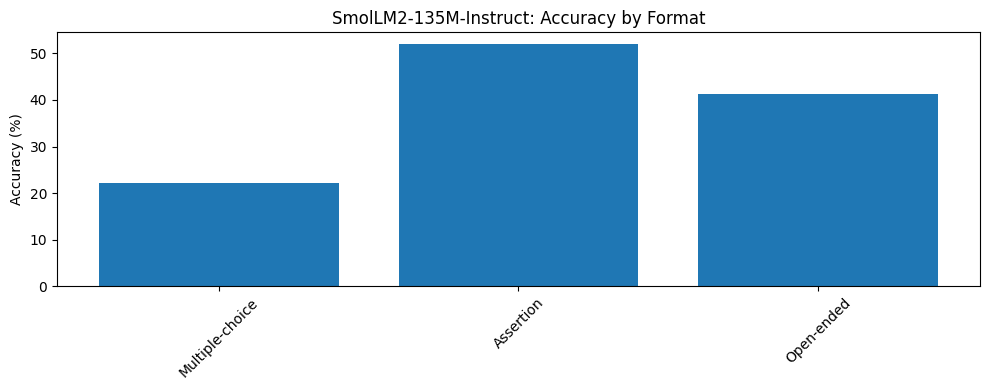

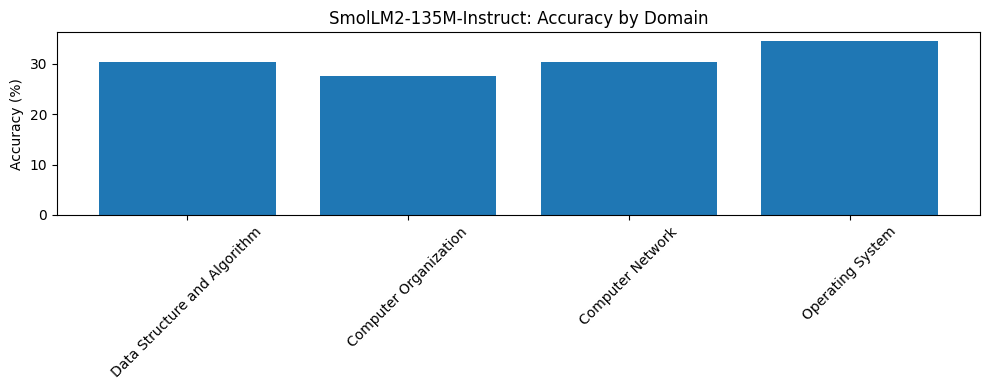

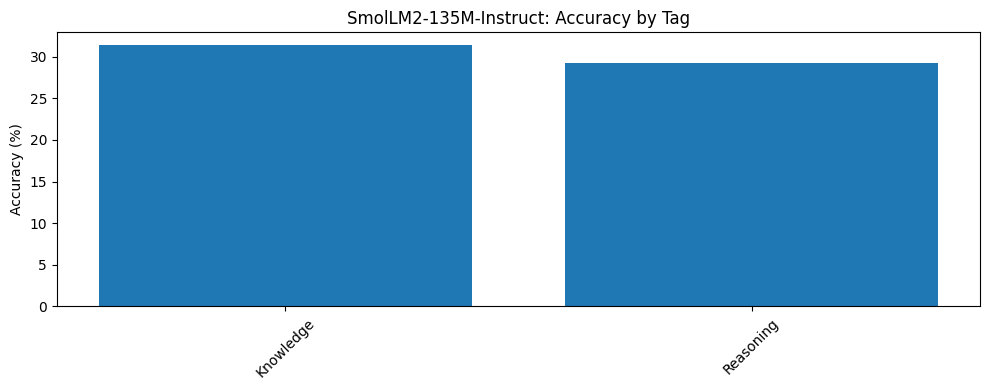

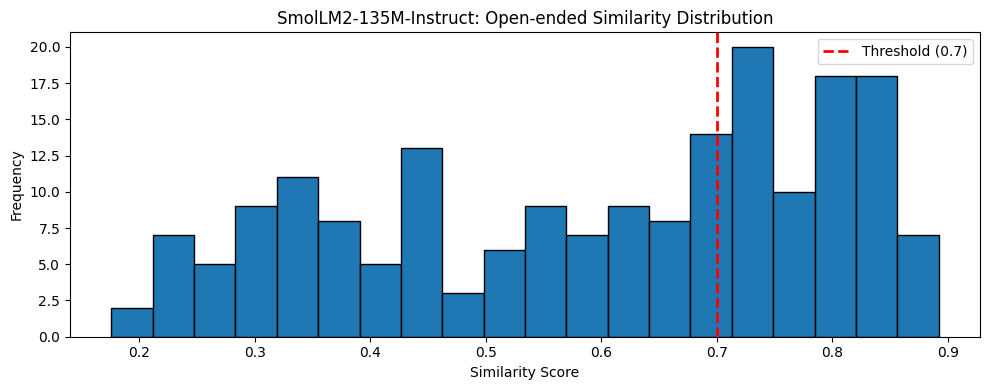

In [85]:
import matplotlib.pyplot as plt

# By Format
format_acc = compute_accuracy_table(smollm2_135m_metrics["by_format"])
plot_accuracy(format_acc, f"{model_label}: Accuracy by Format")

# By Domain
domain_acc = compute_accuracy_table(smollm2_135m_metrics["by_domain"])
plot_accuracy(domain_acc, f"{model_label}: Accuracy by Domain")

# By Tag
tag_acc = compute_accuracy_table(smollm2_135m_metrics["by_tag"])
plot_accuracy(tag_acc, f"{model_label}: Accuracy by Tag")

# Open-ended similarity distribution
plt.figure(figsize=(10, 4))
plt.hist(smollm2_135m_metrics["open_ended_sims"], bins=20, edgecolor="black")
plt.axvline(similarity_threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold ({similarity_threshold})")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.title(f"{model_label}: Open-ended Similarity Distribution")
plt.legend()
plt.tight_layout()
plt.show()

#### 2. SmolLM2-360M (Full Evaluation)

In [86]:
model_label = "SmolLM2-360M"
model_id = "HuggingFaceTB/SmolLM2-360M"

print(f"\n{'='*60}")
print(f"Evaluating: {model_label}")
print(f"{'='*60}")

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)

smollm2_360m_metrics = run_full_evaluation(
    model,
    tokenizer,
    benchmark_questions,
    prompt_template,
    open_ended_prompt_template,
    max_new_tokens_closed=3,
    max_new_tokens_open=max_new_tokens,
    similarity_threshold=similarity_threshold,
)

overall_acc = 100 * smollm2_360m_metrics["overall"]["correct"] / smollm2_360m_metrics["overall"]["total"]
print(f"\nOverall Accuracy: {overall_acc:.2f}%")

format_acc = compute_accuracy_table(smollm2_360m_metrics["by_format"])
print("\nAccuracy by Format:")
for fmt, acc in format_acc.items():
    print(f"  {fmt}: {acc:.2f}%")

print(f"\nOpen-ended mean similarity: {np.mean(smollm2_360m_metrics['open_ended_sims']):.4f}")
print(f"Open-ended median similarity: {np.median(smollm2_360m_metrics['open_ended_sims']):.4f}")


Evaluating: SmolLM2-360M


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


----Question 0/2161----
----Question 1/2161----
----Question 2/2161----
----Question 3/2161----
----Question 4/2161----


Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


...

1431 1411 0.1891421377658844
----Question 2158/2161----


Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


2014 419 0.6427958607673645
----Question 2159/2161----


Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


3522 542 0.6404799222946167
----Question 2160/2161----
2617 514 0.683929443359375

Overall Accuracy: 29.94%

Accuracy by Format:
  Multiple-choice: 26.47%
  Assertion: 42.97%
  Open-ended: 23.28%

Open-ended mean similarity: 0.5340
Open-ended median similarity: 0.5404


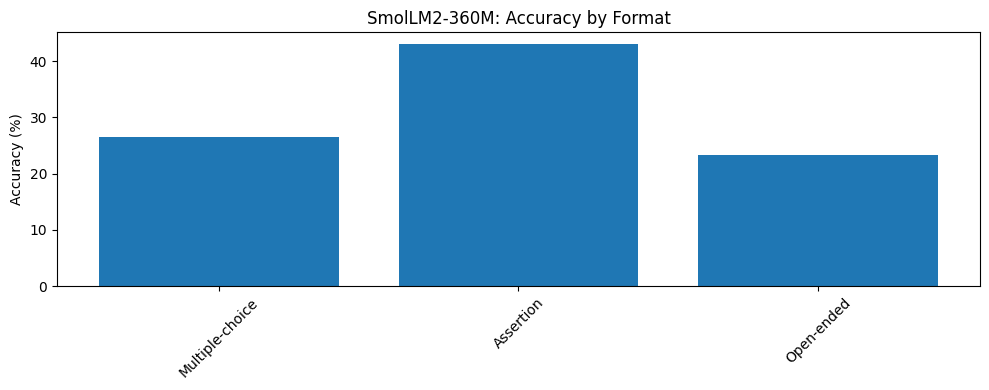

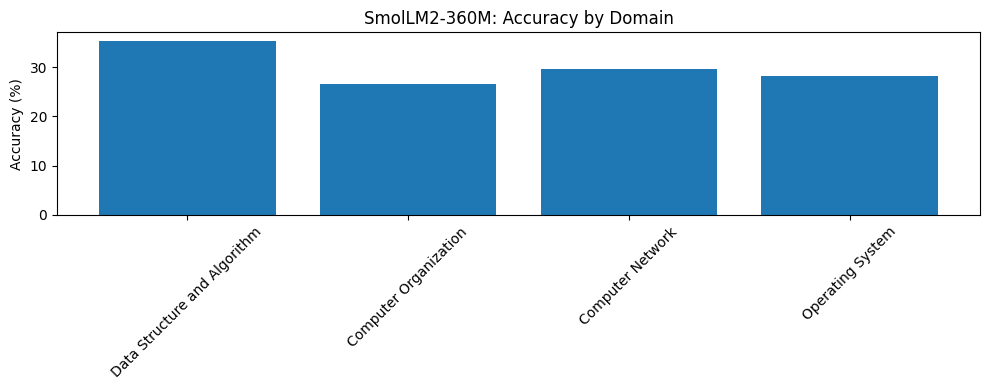

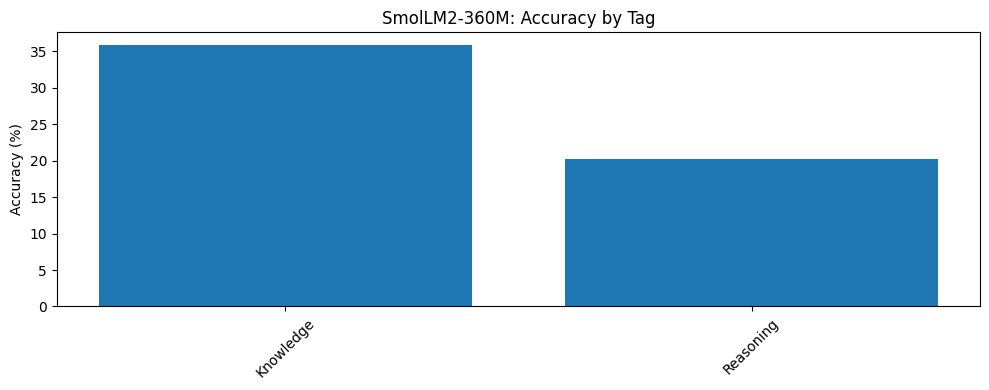

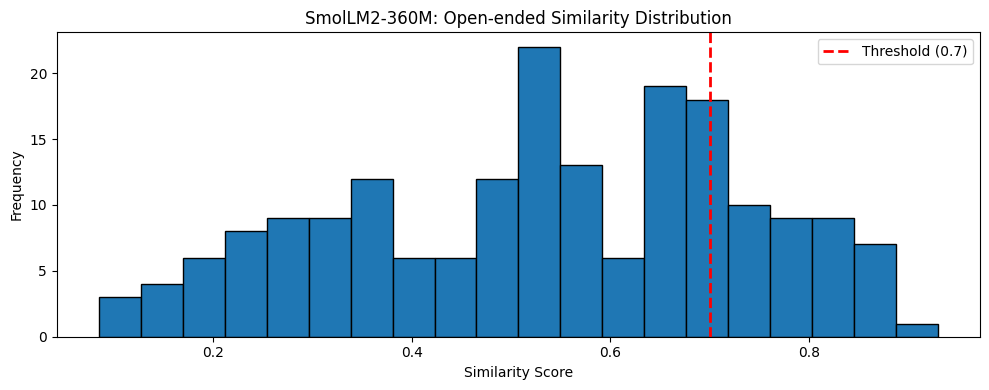

In [87]:
format_acc = compute_accuracy_table(smollm2_360m_metrics["by_format"])
plot_accuracy(format_acc, f"{model_label}: Accuracy by Format")

domain_acc = compute_accuracy_table(smollm2_360m_metrics["by_domain"])
plot_accuracy(domain_acc, f"{model_label}: Accuracy by Domain")

tag_acc = compute_accuracy_table(smollm2_360m_metrics["by_tag"])
plot_accuracy(tag_acc, f"{model_label}: Accuracy by Tag")

plt.figure(figsize=(10, 4))
plt.hist(smollm2_360m_metrics["open_ended_sims"], bins=20, edgecolor="black")
plt.axvline(similarity_threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold ({similarity_threshold})")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.title(f"{model_label}: Open-ended Similarity Distribution")
plt.legend()
plt.tight_layout()
plt.show()

#### 3. Qwen2.5-0.5B-Instruct (Full Evaluation)

In [88]:
model_label = "Qwen2.5-0.5B-Instruct"
model_id = "Qwen/Qwen2.5-0.5B-Instruct"

print(f"\n{'='*60}")
print(f"Evaluating: {model_label}")
print(f"{'='*60}")

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)
model = model.to(device)

qwen25_metrics = run_full_evaluation(
    model,
    tokenizer,
    benchmark_questions,
    prompt_template,
    open_ended_prompt_template,
    max_new_tokens_closed=3,
    max_new_tokens_open=max_new_tokens,
    similarity_threshold=similarity_threshold,
)

overall_acc = 100 * qwen25_metrics["overall"]["correct"] / qwen25_metrics["overall"]["total"]
print(f"\nOverall Accuracy: {overall_acc:.2f}%")

format_acc = compute_accuracy_table(qwen25_metrics["by_format"])
print("\nAccuracy by Format:")
for fmt, acc in format_acc.items():
    print(f"  {fmt}: {acc:.2f}%")

print(f"\nOpen-ended mean similarity: {np.mean(qwen25_metrics['open_ended_sims']):.4f}")
print(f"Open-ended median similarity: {np.median(qwen25_metrics['open_ended_sims']):.4f}")


Evaluating: Qwen2.5-0.5B-Instruct


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


----Question 0/2161----
----Question 1/2161----
----Question 2/2161----
----Question 3/2161----
----Question 4/2161----
----Question 5/2161----
----Question 6/2161----
----Question 7/2161----
----Question 8/2161----
----Question 9/2161----
----Question 10/2161----
----Question 11/2161----
----Question 12/2161----
----Question 13/2161----
----Question 14/2161----
----Question 15/2161----
----Question 16/2161----
----Question 17/2161----
----Question 18/2161----
----Question 19/2161----
----Question 20/2161----
----Question 21/2161----
----Question 22/2161----
----Question 23/2161----
----Question 24/2161----
----Question 25/2161----
----Question 26/2161----
----Question 27/2161----
----Question 28/2161----
----Question 29/2161----
----Question 30/2161----
----Question 31/2161----
----Question 32/2161----
----Question 33/2161----
----Question 34/2161----
----Question 35/2161----
----Question 36/2161----
----Question 37/2161----
----Question 38/2161----
----Question 39/2161----
----Questi

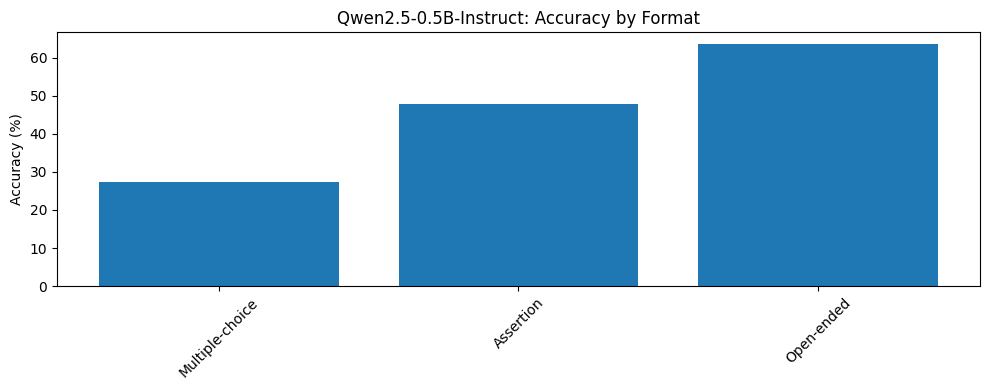

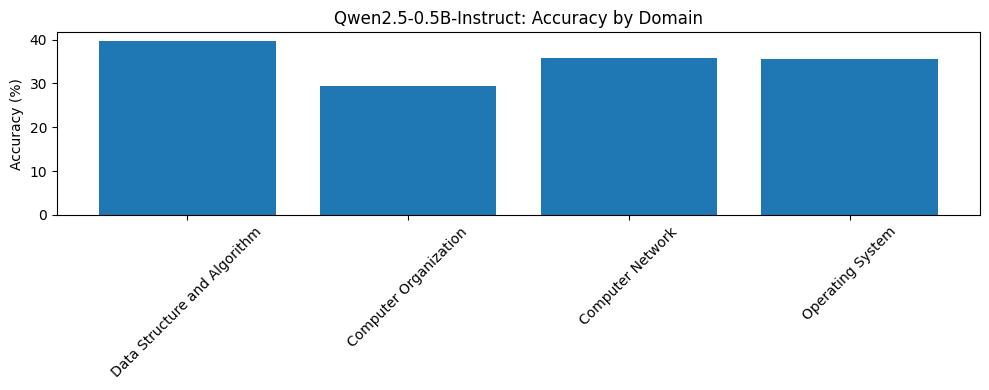

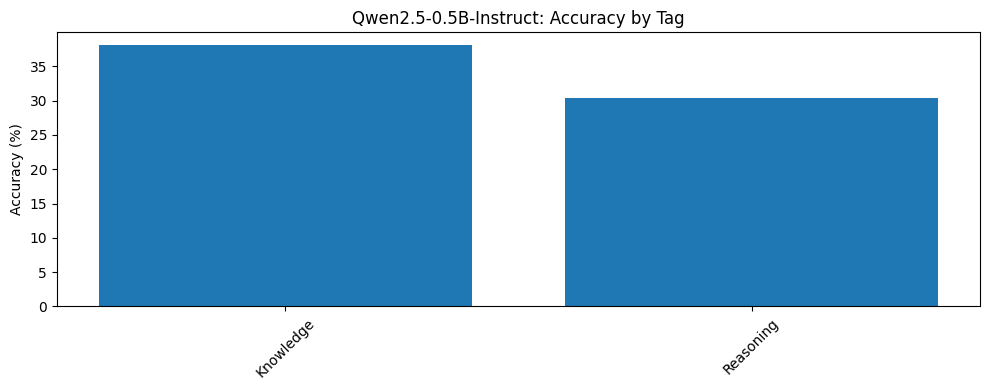

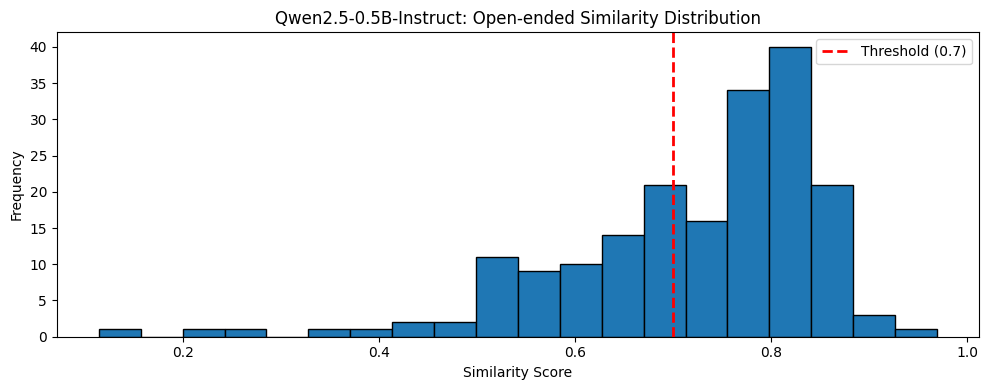

In [89]:
format_acc = compute_accuracy_table(qwen25_metrics["by_format"])
plot_accuracy(format_acc, f"{model_label}: Accuracy by Format")

domain_acc = compute_accuracy_table(qwen25_metrics["by_domain"])
plot_accuracy(domain_acc, f"{model_label}: Accuracy by Domain")

tag_acc = compute_accuracy_table(qwen25_metrics["by_tag"])
plot_accuracy(tag_acc, f"{model_label}: Accuracy by Tag")

plt.figure(figsize=(10, 4))
plt.hist(qwen25_metrics["open_ended_sims"], bins=20, edgecolor="black")
plt.axvline(similarity_threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold ({similarity_threshold})")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.title(f"{model_label}: Open-ended Similarity Distribution")
plt.legend()
plt.tight_layout()
plt.show()

#### 4. Qwen3-0.6B (Full Evaluation)

In [90]:
model_label = "Qwen3-0.6B"
model_id = "Qwen/Qwen3-0.6B"

print(f"\n{'='*60}")
print(f"Evaluating: {model_label}")
print(f"{'='*60}")

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)
model = model.to(device)

qwen3_metrics = run_full_evaluation(
    model,
    tokenizer,
    benchmark_questions,
    prompt_template,
    open_ended_prompt_template,
    max_new_tokens_closed=3,
    max_new_tokens_open=max_new_tokens,
    similarity_threshold=similarity_threshold,
)

overall_acc = 100 * qwen3_metrics["overall"]["correct"] / qwen3_metrics["overall"]["total"]
print(f"\nOverall Accuracy: {overall_acc:.2f}%")

format_acc = compute_accuracy_table(qwen3_metrics["by_format"])
print("\nAccuracy by Format:")
for fmt, acc in format_acc.items():
    print(f"  {fmt}: {acc:.2f}%")

print(f"\nOpen-ended mean similarity: {np.mean(qwen3_metrics['open_ended_sims']):.4f}")
print(f"Open-ended median similarity: {np.median(qwen3_metrics['open_ended_sims']):.4f}")


Evaluating: Qwen3-0.6B


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


----Question 0/2161----
----Question 1/2161----
----Question 2/2161----
----Question 3/2161----
----Question 4/2161----
----Question 5/2161----
----Question 6/2161----
----Question 7/2161----
----Question 8/2161----
----Question 9/2161----
----Question 10/2161----
----Question 11/2161----
----Question 12/2161----
----Question 13/2161----
----Question 14/2161----
----Question 15/2161----
----Question 16/2161----
----Question 17/2161----
----Question 18/2161----
----Question 19/2161----
----Question 20/2161----
----Question 21/2161----
----Question 22/2161----
----Question 23/2161----
----Question 24/2161----
----Question 25/2161----
----Question 26/2161----
----Question 27/2161----
----Question 28/2161----
----Question 29/2161----
----Question 30/2161----
----Question 31/2161----
----Question 32/2161----
----Question 33/2161----
----Question 34/2161----
----Question 35/2161----
----Question 36/2161----
----Question 37/2161----
----Question 38/2161----
----Question 39/2161----
----Questi

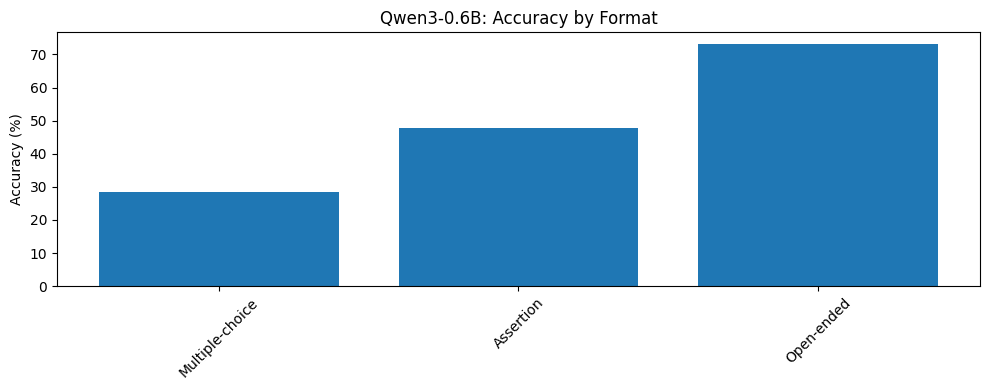

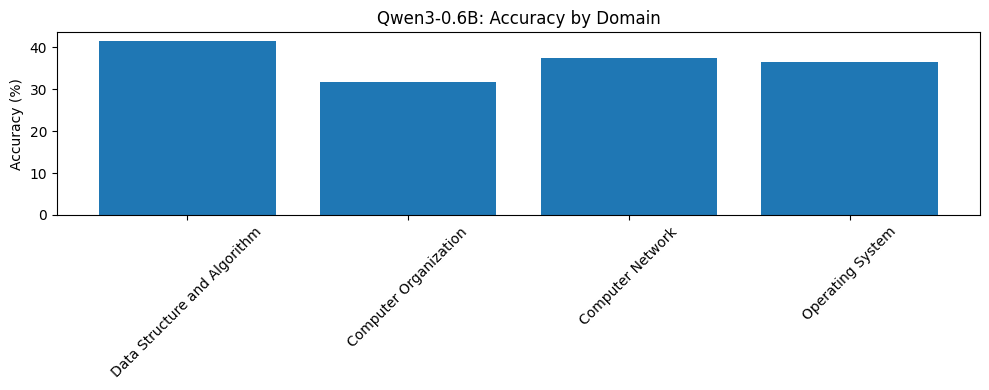

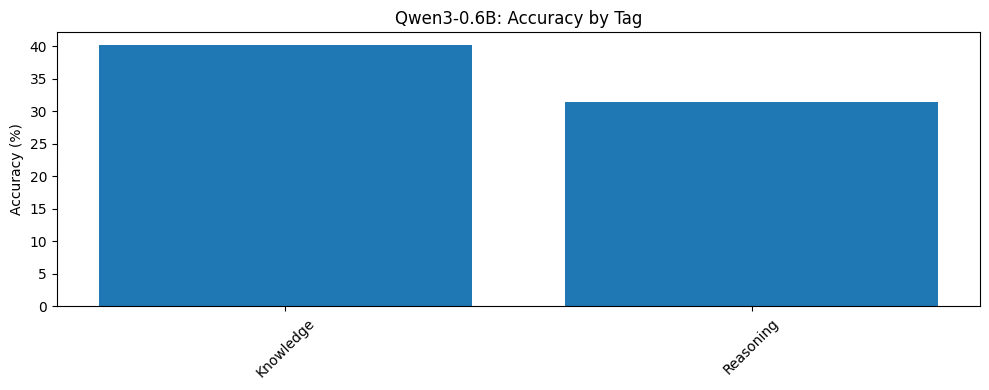

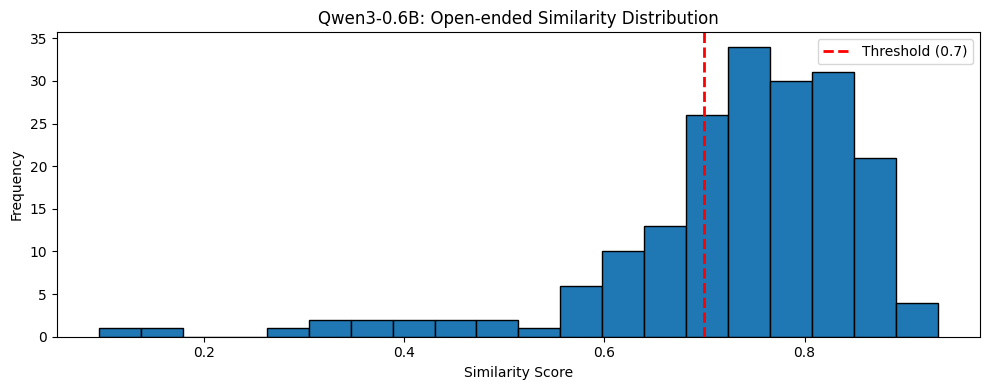

In [91]:
format_acc = compute_accuracy_table(qwen3_metrics["by_format"])
plot_accuracy(format_acc, f"{model_label}: Accuracy by Format")

domain_acc = compute_accuracy_table(qwen3_metrics["by_domain"])
plot_accuracy(domain_acc, f"{model_label}: Accuracy by Domain")

tag_acc = compute_accuracy_table(qwen3_metrics["by_tag"])
plot_accuracy(tag_acc, f"{model_label}: Accuracy by Tag")

plt.figure(figsize=(10, 4))
plt.hist(qwen3_metrics["open_ended_sims"], bins=20, edgecolor="black")
plt.axvline(similarity_threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold ({similarity_threshold})")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.title(f"{model_label}: Open-ended Similarity Distribution")
plt.legend()
plt.tight_layout()
plt.show()

#### 5. TinyLlama-1.1B-Chat (Full Evaluation)

In [92]:
model_label = "TinyLlama-1.1B-Chat"
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print(f"\n{'='*60}")
print(f"Evaluating: {model_label}")
print(f"{'='*60}")

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)
model = model.to(device)

tinyllama_metrics = run_full_evaluation(
    model,
    tokenizer,
    benchmark_questions,
    prompt_template,
    open_ended_prompt_template,
    max_new_tokens_closed=3,
    max_new_tokens_open=max_new_tokens,
    similarity_threshold=similarity_threshold,
)

overall_acc = 100 * tinyllama_metrics["overall"]["correct"] / tinyllama_metrics["overall"]["total"]
print(f"\nOverall Accuracy: {overall_acc:.2f}%")

format_acc = compute_accuracy_table(tinyllama_metrics["by_format"])
print("\nAccuracy by Format:")
for fmt, acc in format_acc.items():
    print(f"  {fmt}: {acc:.2f}%")

print(f"\nOpen-ended mean similarity: {np.mean(tinyllama_metrics['open_ended_sims']):.4f}")
print(f"Open-ended median similarity: {np.median(tinyllama_metrics['open_ended_sims']):.4f}")


Evaluating: TinyLlama-1.1B-Chat


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

----Question 0/2161----
----Question 1/2161----
----Question 2/2161----
----Question 3/2161----
----Question 4/2161----
----Question 5/2161----
----Question 6/2161----
----Question 7/2161----
----Question 8/2161----
----Question 9/2161----
----Question 10/2161----
----Question 11/2161----
----Question 12/2161----
----Question 13/2161----
----Question 14/2161----
----Question 15/2161----
----Question 16/2161----
----Question 17/2161----
----Question 18/2161----
----Question 19/2161----
----Question 20/2161----
----Question 21/2161----
----Question 22/2161----
----Question 23/2161----
----Question 24/2161----
----Question 25/2161----
----Question 26/2161----
----Question 27/2161----
----Question 28/2161----
----Question 29/2161----
----Question 30/2161----
----Question 31/2161----
----Question 32/2161----
----Question 33/2161----
----Question 34/2161----
----Question 35/2161----
----Question 36/2161----
----Question 37/2161----
----Question 38/2161----
----Question 39/2161----
----Questi

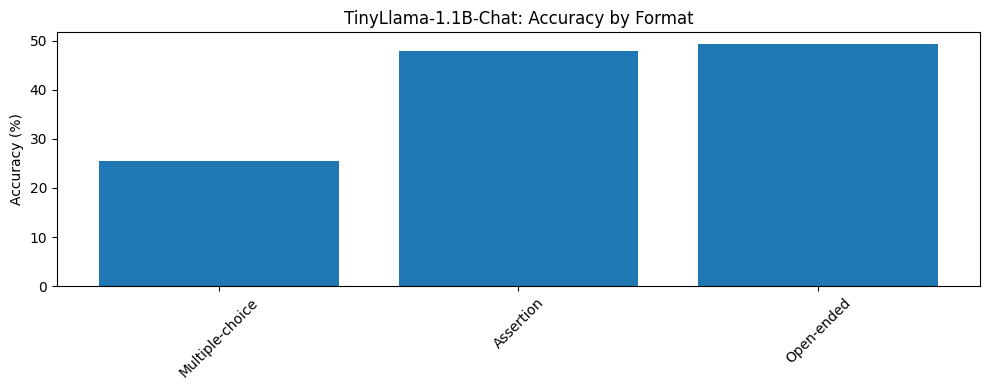

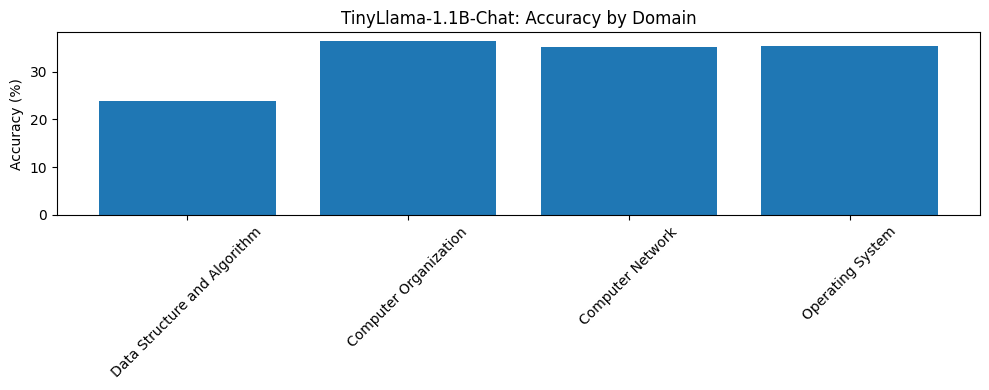

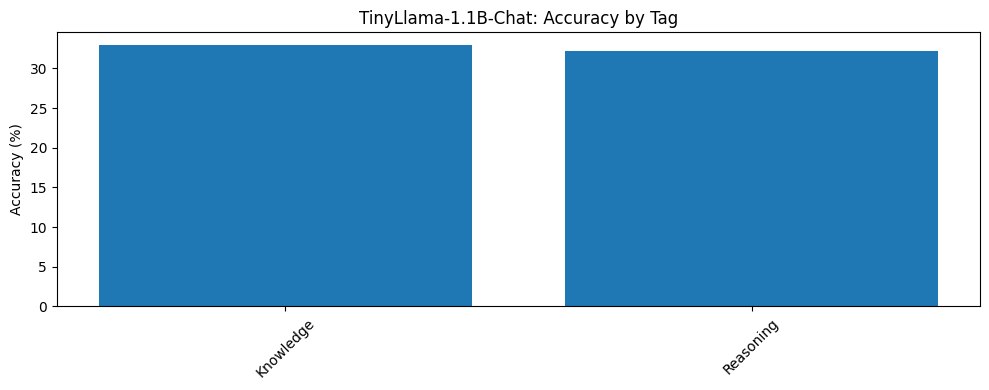

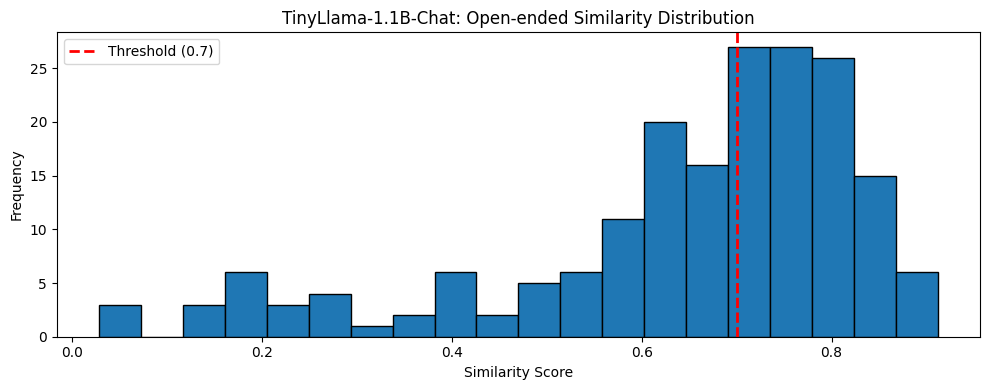

In [93]:
format_acc = compute_accuracy_table(tinyllama_metrics["by_format"])
plot_accuracy(format_acc, f"{model_label}: Accuracy by Format")

domain_acc = compute_accuracy_table(tinyllama_metrics["by_domain"])
plot_accuracy(domain_acc, f"{model_label}: Accuracy by Domain")

tag_acc = compute_accuracy_table(tinyllama_metrics["by_tag"])
plot_accuracy(tag_acc, f"{model_label}: Accuracy by Tag")

plt.figure(figsize=(10, 4))
plt.hist(tinyllama_metrics["open_ended_sims"], bins=20, edgecolor="black")
plt.axvline(similarity_threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold ({similarity_threshold})")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.title(f"{model_label}: Open-ended Similarity Distribution")
plt.legend()
plt.tight_layout()
plt.show()

#### 6. Gemma3-270M-It (Full Evaluation)

In [94]:
model_label = "Gemma3-270M-It"
model_id = "google/gemma-3-270m-it"

print(f"\n{'='*60}")
print(f"Evaluating: {model_label}")
print(f"{'='*60}")

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)
model = model.to(device)

gemma3_metrics = run_full_evaluation(
    model,
    tokenizer,
    benchmark_questions,
    prompt_template,
    open_ended_prompt_template,
    max_new_tokens_closed=3,
    max_new_tokens_open=max_new_tokens,
    similarity_threshold=similarity_threshold,
)

overall_acc = 100 * gemma3_metrics["overall"]["correct"] / gemma3_metrics["overall"]["total"]
print(f"\nOverall Accuracy: {overall_acc:.2f}%")

format_acc = compute_accuracy_table(gemma3_metrics["by_format"])
print("\nAccuracy by Format:")
for fmt, acc in format_acc.items():
    print(f"  {fmt}: {acc:.2f}%")

print(f"\nOpen-ended mean similarity: {np.mean(gemma3_metrics['open_ended_sims']):.4f}")
print(f"Open-ended median similarity: {np.median(gemma3_metrics['open_ended_sims']):.4f}")


Evaluating: Gemma3-270M-It


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


----Question 0/2161----
----Question 1/2161----
----Question 2/2161----
----Question 3/2161----
----Question 4/2161----


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


...

4663 1411 0.24621863663196564
----Question 2158/2161----


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


4810 419 0.2758815884590149
----Question 2159/2161----


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


2520 542 0.29420754313468933
----Question 2160/2161----
4068 514 0.3764650225639343

Overall Accuracy: 31.33%

Accuracy by Format:
  Multiple-choice: 27.14%
  Assertion: 48.07%
  Open-ended: 20.63%

Open-ended mean similarity: 0.5067
Open-ended median similarity: 0.4811


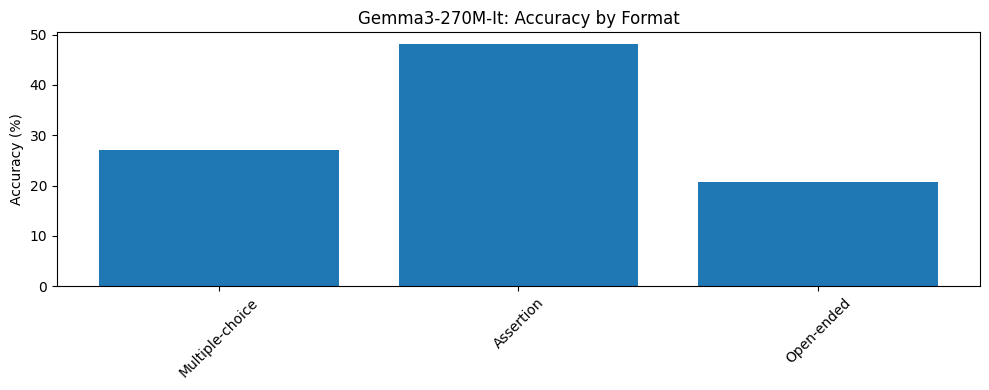

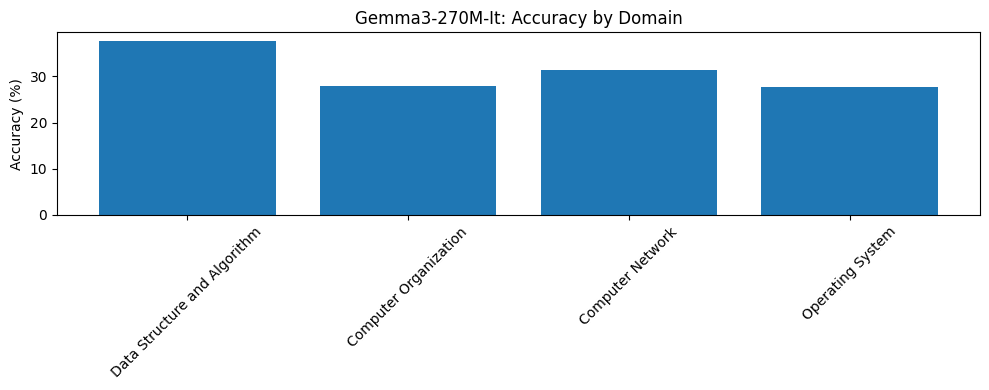

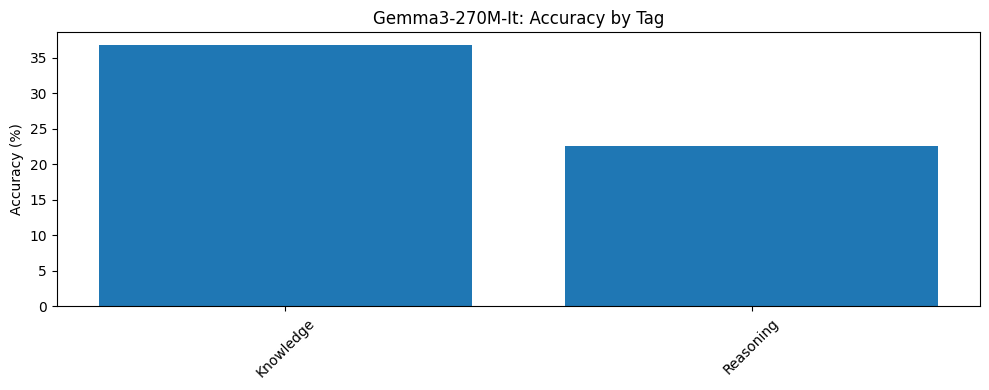

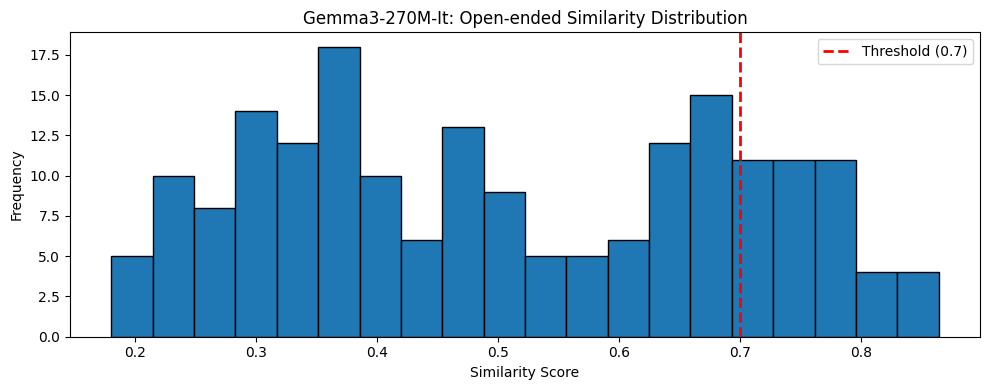

In [95]:
format_acc = compute_accuracy_table(gemma3_metrics["by_format"])
plot_accuracy(format_acc, f"{model_label}: Accuracy by Format")

domain_acc = compute_accuracy_table(gemma3_metrics["by_domain"])
plot_accuracy(domain_acc, f"{model_label}: Accuracy by Domain")

tag_acc = compute_accuracy_table(gemma3_metrics["by_tag"])
plot_accuracy(tag_acc, f"{model_label}: Accuracy by Tag")

plt.figure(figsize=(10, 4))
plt.hist(gemma3_metrics["open_ended_sims"], bins=20, edgecolor="black")
plt.axvline(similarity_threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold ({similarity_threshold})")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.title(f"{model_label}: Open-ended Similarity Distribution")
plt.legend()
plt.tight_layout()
plt.show()

### Overall Summary and Comparison

In [97]:
import pandas as pd

# Create summary dataframe
models_data = {
    "Model": [
        "SmolLM2-135M-Instruct",
        "SmolLM2-360M",
        "Qwen2.5-0.5B-Instruct",
        "Qwen3-0.6B",
        "TinyLlama-1.1B-Chat",
        "Gemma3-270M-It"
    ],
    "Overall Accuracy": [
        100 * smollm2_135m_metrics["overall"]["correct"] / smollm2_135m_metrics["overall"]["total"],
        100 * smollm2_360m_metrics["overall"]["correct"] / smollm2_360m_metrics["overall"]["total"],
        100 * qwen25_metrics["overall"]["correct"] / qwen25_metrics["overall"]["total"],
        100 * qwen3_metrics["overall"]["correct"] / qwen3_metrics["overall"]["total"],
        100 * tinyllama_metrics["overall"]["correct"] / tinyllama_metrics["overall"]["total"],
        100 * gemma3_metrics["overall"]["correct"] / gemma3_metrics["overall"]["total"],
    ],
}

summary_df = pd.DataFrame(models_data)
summary_df = summary_df.sort_values("Overall Accuracy", ascending=False)

print("\n" + "="*70)
print("FULL EVALUATION LEADERBOARD (MCQs + Assertions + Open-ended)")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)


FULL EVALUATION LEADERBOARD (MCQs + Assertions + Open-ended)
                Model  Overall Accuracy
           Qwen3-0.6B         36.834799
Qwen2.5-0.5B-Instruct         35.122628
  TinyLlama-1.1B-Chat         32.623785
       Gemma3-270M-It         31.328089
SmolLM2-135M-Instruct         30.541416
         SmolLM2-360M         29.939843


## Results 
---
### Evaluation 1 ( MCQs + Assertions ) 
#### Best base model: **Qwen3-0.6B**
#### Results:
1. Qwen3-0.6B - 33.46855983772819
2. Qwen2.5 - 0.5B - 32.454361054766736
3. Gemma3 - 270M - 32.35294117647059
4. SMOL LM2 - 360M - 31.135902636916835
5. TinyLlama - 1.1B - 30.831643002028397
6. SMOL LM2 - 135M - 27.687626774847867
---
### Evaluation 2 ( MCQs + Assertions + Option Wise Analysis) 
#### Best base model: **Qwen3-0.6B**
#### Results:
1. Qwen3-0.6B - 33.46855983772819
   - MCQs
       - A : 1376
       - B : 2
       - C : 10
       - D : 93
       - NONE: 0
   - Assertion
       - True : 491
       - False : 0
       - None : 0
2. Qwen2.5 - 0.5B - 32.454361054766736
   - MCQs
       - A : 1445
       - B : 1
       - C : 0
       - D : 14
       - NONE: 13
   - Assertion
       - True : 491
       - False : 0
       - None : 0
3. Gemma3 - 270M - 32.35294117647059
   - MCQs
       - A : 1479
       - B : 1
       - C : 0
       - D : 0
       - NONE: 1
   - Assertion
       - True : 490
       - False : 1
       - None : 0
4. SMOL LM2 - 360M - 31.135902636916835
   - MCQs
       - A : 1406
       - B : 0
       - C : 5
       - D : 12
       - NONE: 50
   - Assertion
       - True : 452
       - False : 0
       - None : 39
5. TinyLlama - 1.1B - 30.831643002028397
   - MCQs
       - A : 184
       - B : 1182
       - C : 6
       - D : 92
       - NONE: 17
   - Assertion
       - True : 491
       - False : 0
       - None : 0
6. SMOL LM2 - 135M - 30.324543610547668
   - MCQs
       - A : 680
       - B : 84
       - C : 6
       - D : 697
       - NONE: 14
   - Assertion
       - True : 209
       - False : 282
       - None : 0
---
### Evaluation 3 ( MCQs + Assertions + Open Ended Questions + Detailed Analysis) 
#### Best base model: **Qwen3-0.6B**
#### Results:
1. Qwen3-0.6B
    - Overall Accuracy: 36.83%
    - Accuracy by Format:
      - Multiple-choice: 28.56%
      - Assertion: 47.86%
      - Open-ended: 73.02%
    - Open-ended mean similarity: 0.7321
    - Open-ended median similarity: 0.7574
2. Qwen2.5-0.5B
   - Overall Accuracy: 35.12%
   - Accuracy by Format:
     - Multiple-choice: 27.28%
     - Assertion: 47.86%
     - Open-ended: 63.49%
   - Open-ended mean similarity: 0.7215
   - Open-ended median similarity: 0.7695
3. Tinyllama 1.1B
   - Overall Accuracy: 32.62%
   - Accuracy by Format:
   - - Multiple-choice: 25.46%
     - Assertion: 47.86%
     - Open-ended: 49.21%
   - Open-ended mean similarity: 0.6444
   - Open-ended median similarity: 0.6996
4. Gemma3 - 270M
   - Overall Accuracy: 31.33%
    - Accuracy by Format:
        - Multiple-choice: 27.14%
        - Assertion: 48.07%
        - Open-ended: 20.63%
    - Open-ended mean similarity: 0.5067
    - Open-ended median similarity: 0.4811
5. SMOLLM2 135M
   - Overall Accuracy: 30.54%
   - Accuracy by Format:
     - Multiple-choice: 22.08%
     - Assertion: 51.93%
     - Open-ended: 41.27%
   - Open-ended mean similarity: 0.5965
   - Open-ended median similarity: 0.6456
6. SMOLLM2 360M
    - Overall Accuracy: 29.94%
    - Accuracy by Format:
      - Multiple-choice: 26.47%
      - Assertion: 42.97%
      - Open-ended: 23.28%
    - Open-ended mean similarity: 0.5340
    - Open-ended median similarity: 0.5404   


## Conclusion

1. **MCQ accuracy is dominated by option bias, not reasoning**
   All models show strong answer-letter priors (e.g., collapsing to “A” or “B”), making MCQ accuracy an unreliable indicator of true understanding for small models.

2. **Assertion questions provide weak evaluative signal**
   Assertion accuracy stays near ~50% across models, largely reflecting binary bias rather than logical competence; useful only to detect extreme failures.

3. **Open-ended, embedding-based evaluation is the most meaningful metric**
   Semantic similarity cleanly separates models and produces stable rankings, unlike closed-form accuracy.

4. **Pretraining quality matters more than model size**
   Qwen3-0.6B and Qwen2.5-0.5B significantly outperform similarly sized or larger models, indicating superior pretraining and instruction alignment.

5. **No model shows natural CS domain specialization**
   Performance is uniformly low across OS, CN, CO, and DSA, justifying domain-specific fine-tuning or modular (MoE/LoRA) specialization as the next step.
